Dataset Shape: (20640, 10)

Column Names:
 Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

================ OUTLIER SUMMARY (IQR Method) ================

              Feature          Q1          Q3  Lower Bound  Upper Bound  \
0           longitude    -121.800    -118.010     -127.485     -112.325   
1            latitude      33.930      37.710       28.260       43.380   
2  housing_median_age      18.000      37.000      -10.500       65.500   
3         total_rooms    1447.750    3148.000    -1102.625     5698.375   
4      total_bedrooms     296.000     647.000     -230.500     1173.500   
5          population     787.000    1725.000     -620.000     3132.000   
6          households     280.000     605.000     -207.500     1092.500   
7       median_income       2.563       4.743       -0.706        8.013   
8  medi

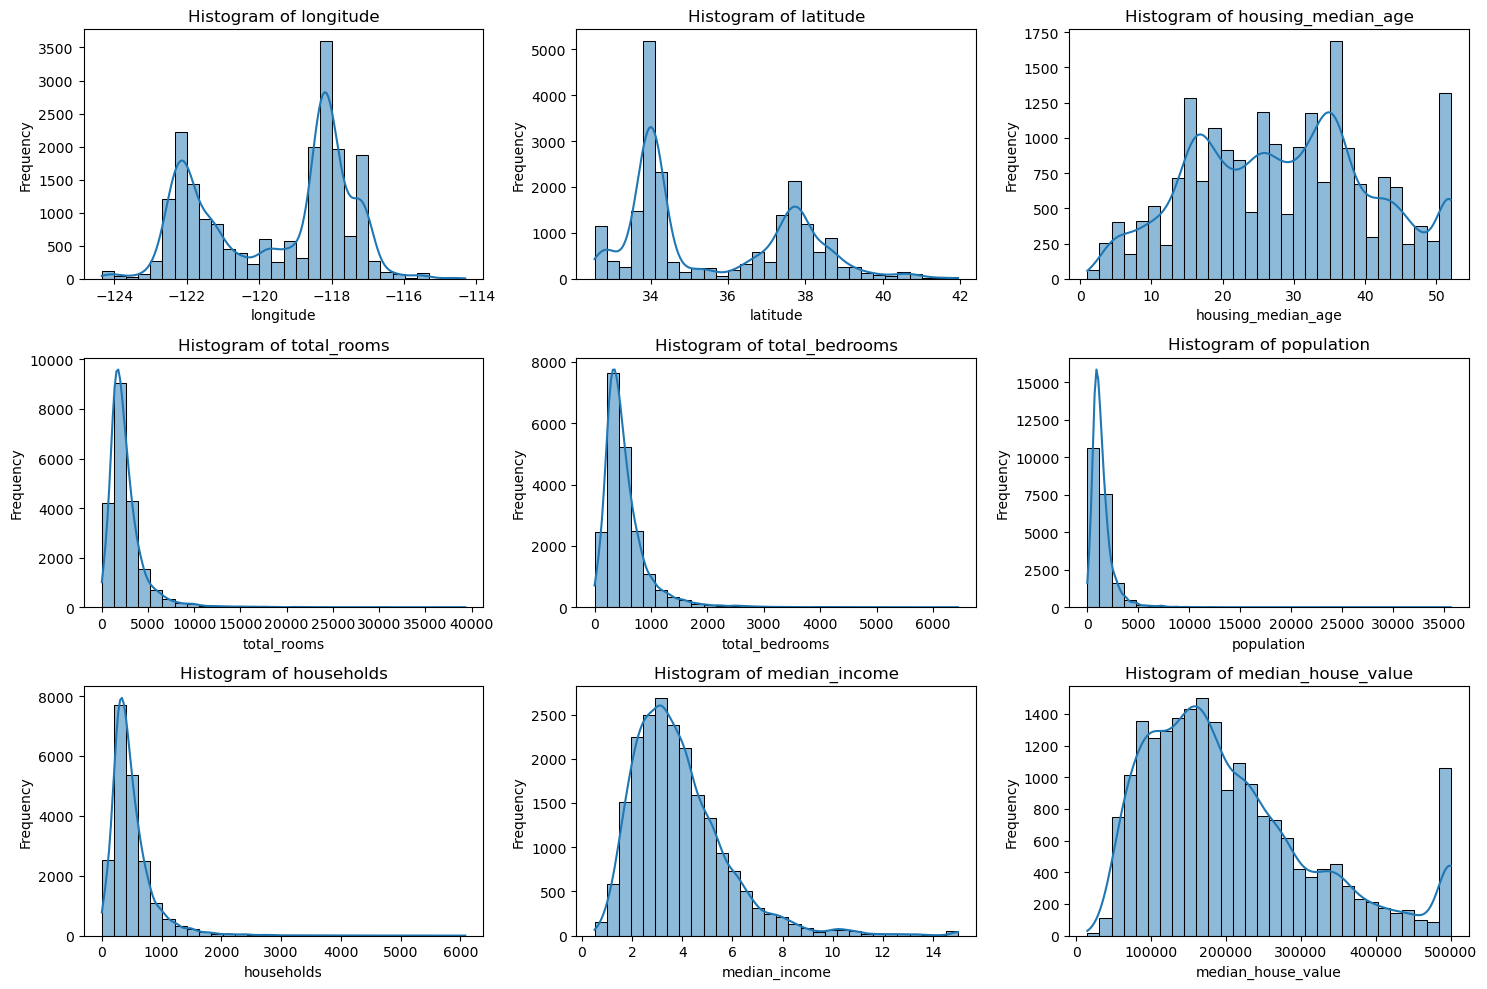

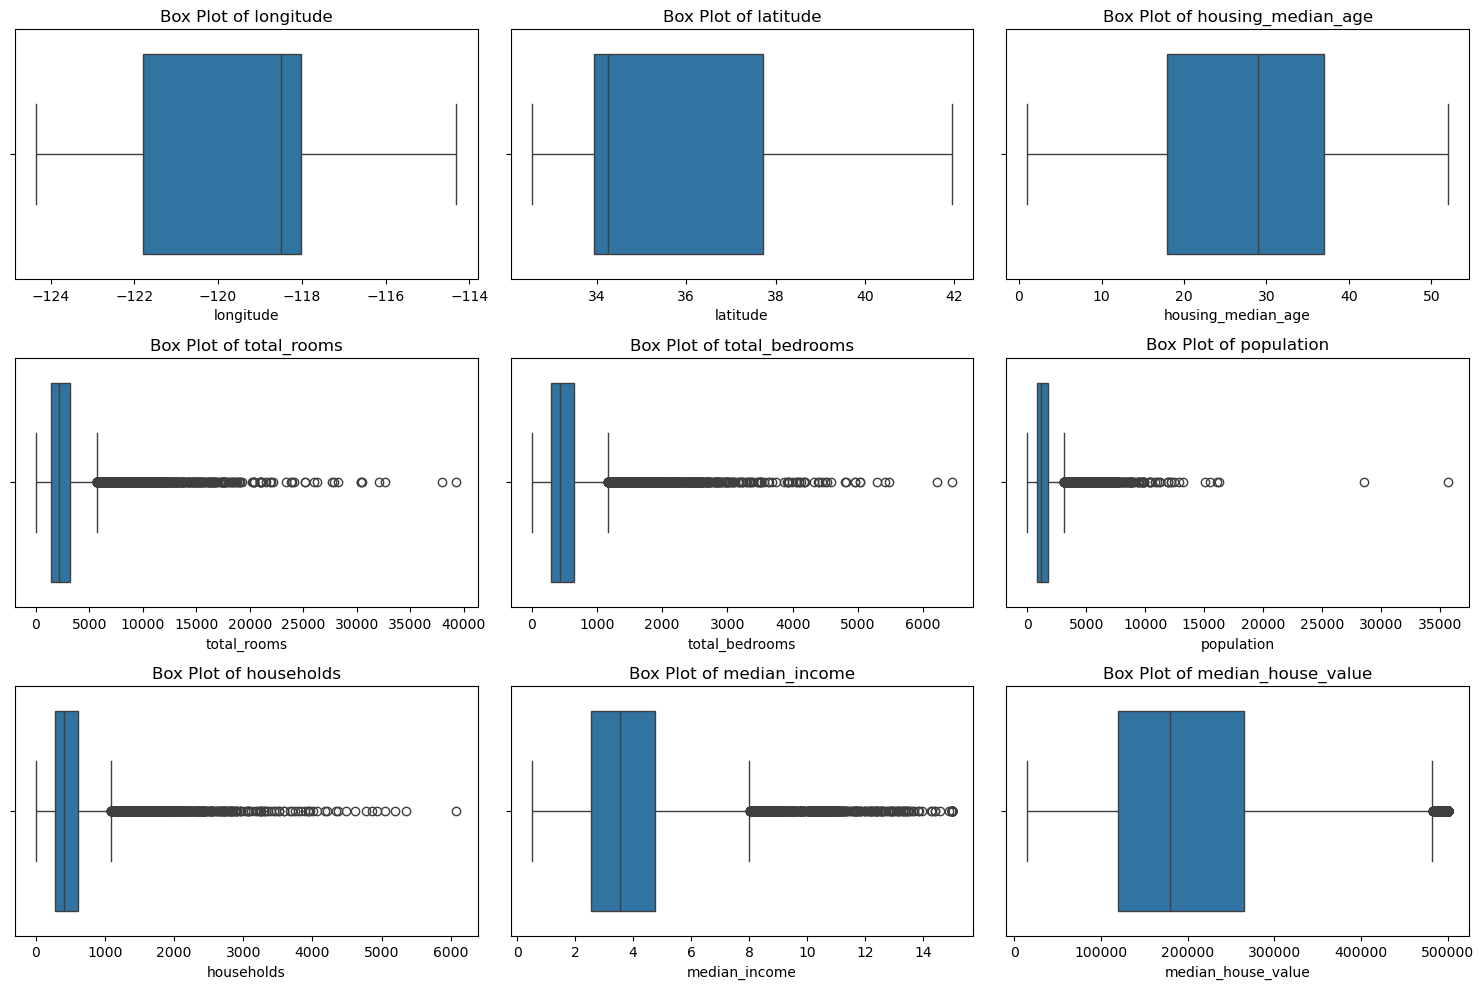

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "/home/rnsit/1RN23CS138/pn.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)

numerical_features = df.select_dtypes(include=[np.number]).columns

print("\n================ OUTLIER SUMMARY (IQR Method) ================\n")

outlier_summary = []

for feature in numerical_features:
    
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    outlier_count = outliers.shape[0]
    total_count = df.shape[0]
    percentage = (outlier_count / total_count) * 100
    
    outlier_summary.append([
        feature, 
        round(Q1,3), 
        round(Q3,3), 
        round(lower_bound,3), 
        round(upper_bound,3), 
        outlier_count, 
        round(percentage,2)
    ])

outlier_df = pd.DataFrame(outlier_summary, 
                          columns=["Feature", "Q1", "Q3", 
                                   "Lower Bound", "Upper Bound", 
                                   "Outlier Count", "Outlier %"])

print(outlier_df)

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[feature])
    plt.title(f"Box Plot of {feature}")
    plt.xlabel(feature)

plt.tight_layout()
plt.show()


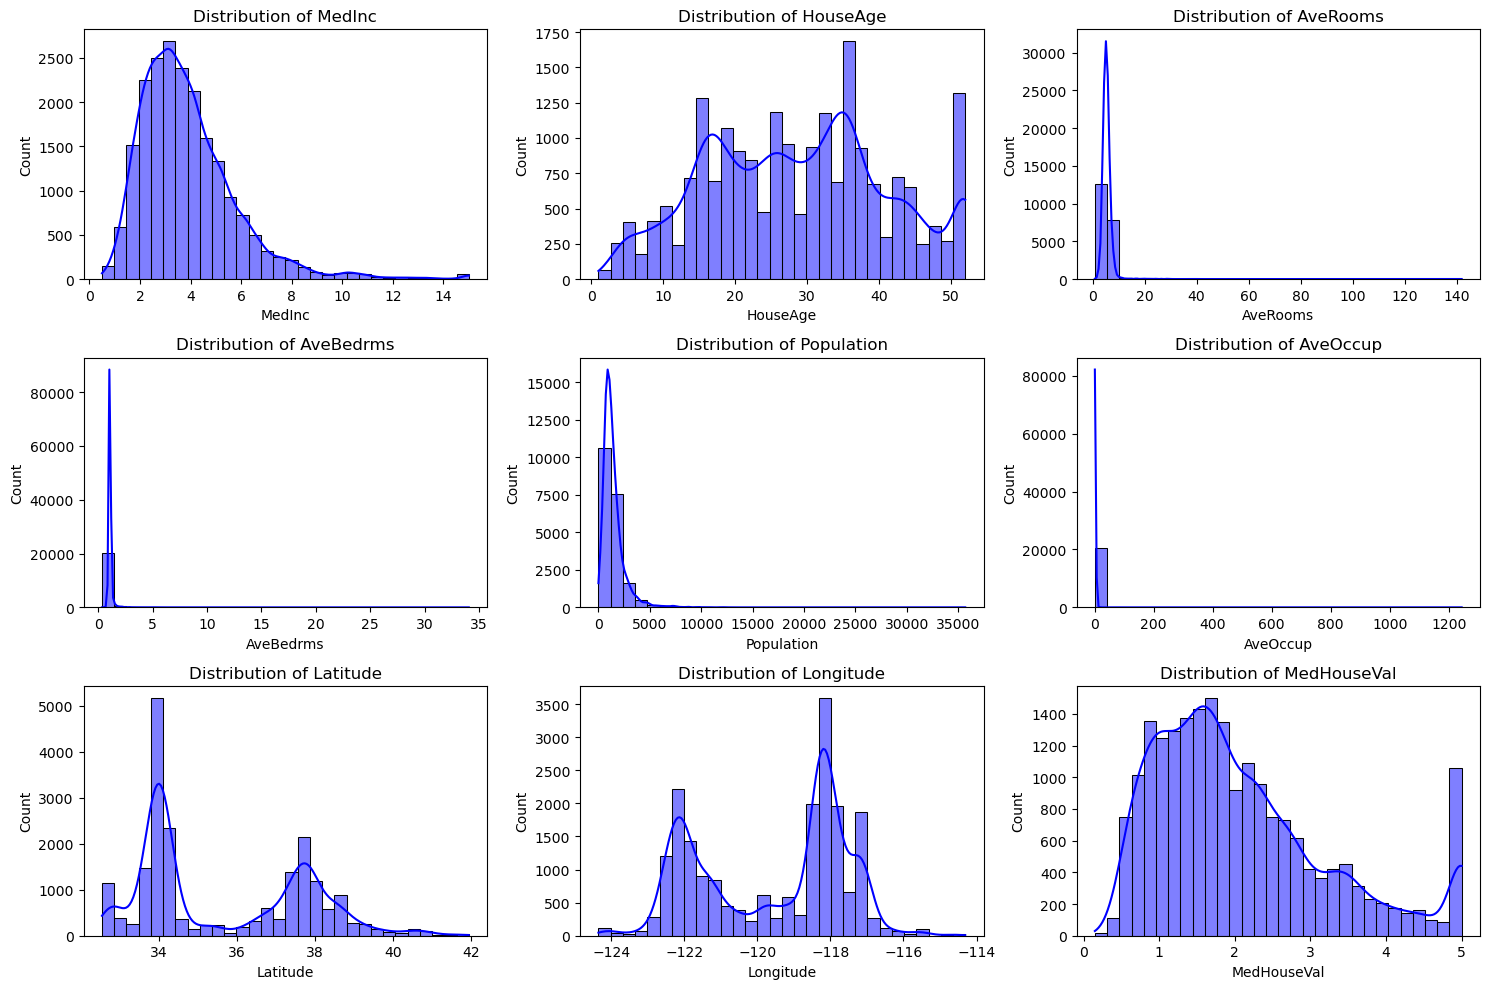

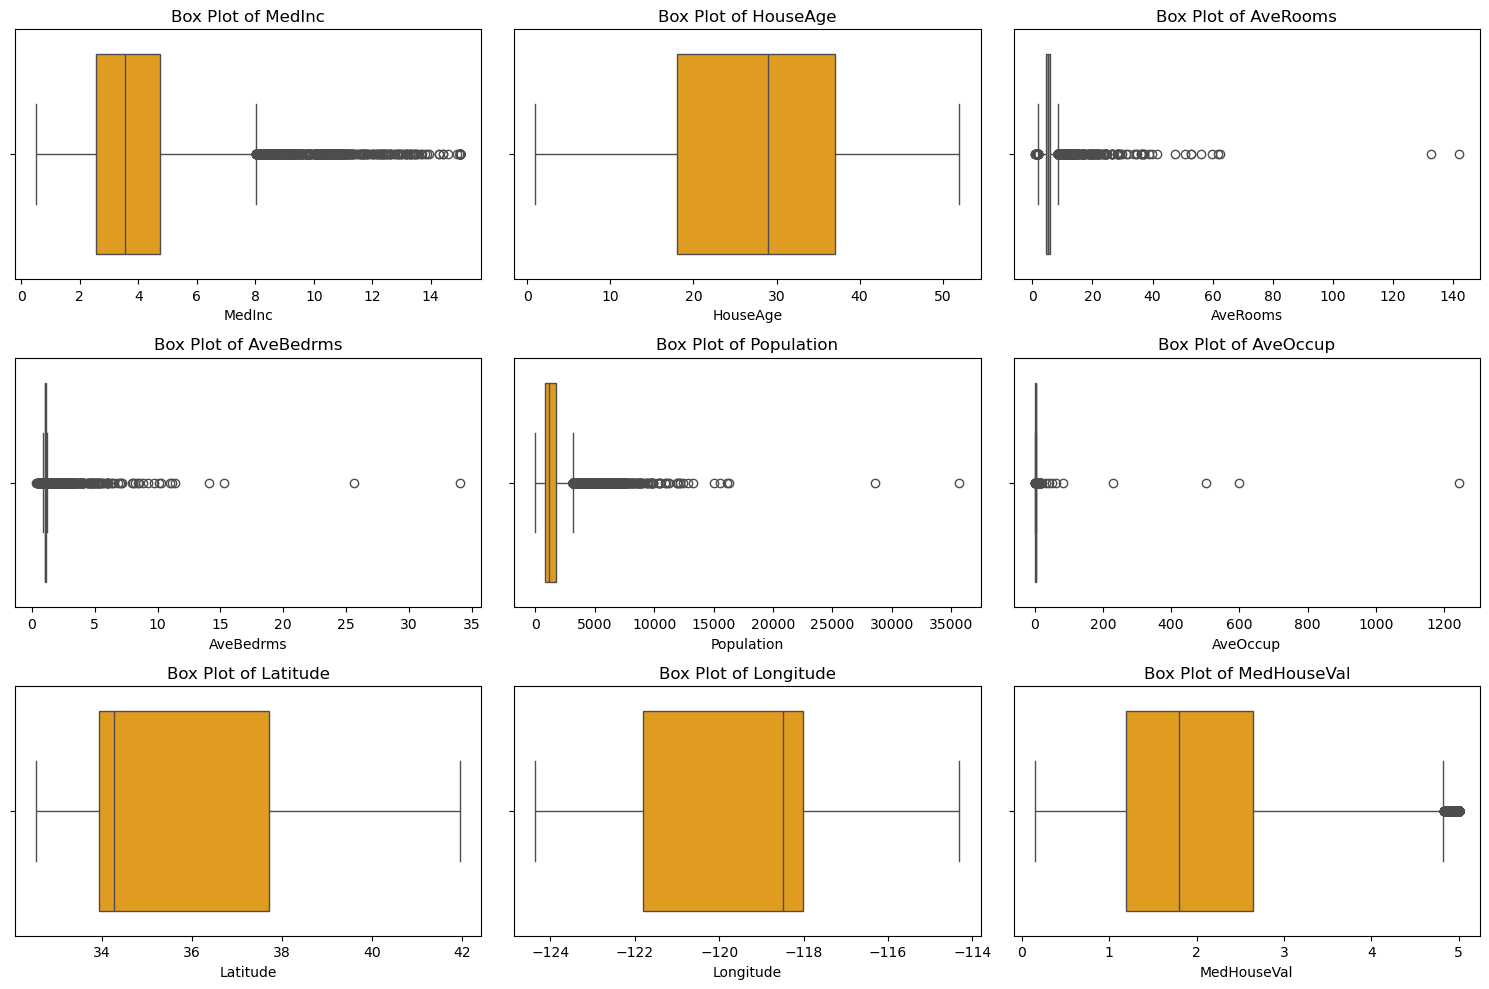

Outliers Detection:
MedInc: 681 outliers
HouseAge: 0 outliers
AveRooms: 511 outliers
AveBedrms: 1424 outliers
Population: 1196 outliers
AveOccup: 711 outliers
Latitude: 0 outliers
Longitude: 0 outliers
MedHouseVal: 1071 outliers

Dataset Summary:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Lon

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
housing_df = data.frame

numerical_features = housing_df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(housing_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=housing_df[feature], color='orange')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

print("Outliers Detection:")
outliers_summary = {}
for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = housing_df[(housing_df[feature] < lower_bound) | (housing_df[feature] > upper_bound)]
    outliers_summary[feature] = len(outliers)
    print(f"{feature}: {len(outliers)} outliers")

print("\nDataset Summary:")
print(housing_df.describe())
